# Multilingual Health QA — Exploratory Data Analysis

**Goal.** Answer one question with evidence: *what is the best modelling strategy for this dataset?*
Every section states **why** we run it, **what** insight we want, and **how** it changes our modelling
choices, and ends with **Modelling Implications**. Findings that affect retrieval, prompting, reranking,
fine-tuning, evaluation or post-processing are appended to `MODELLING_DECISIONS.md`.

**Dataset.** Sexual & reproductive health Q/A across 8 language-country subsets (English + Akan, Amharic,
Luganda, Swahili) from Ghana, Uganda, Kenya, Ethiopia. Submission is scored on **three** targets:
ROUGE-L F1, ROUGE-1 F1, and an **LLM judge**.

**Reproducibility.** All helpers live in `src/health_eda`. Tables → `outputs/tables`, figures →
`outputs/figures`, artefacts (embeddings, topics, indices) → `outputs/artifacts`. Seeds are fixed.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))  # notebook lives in notebooks/
sys.path.insert(0, str(Path.cwd() / "src"))          # or run from repo root

import numpy as np, pandas as pd
from IPython.display import display, Image

from health_eda import config as C, io_utils as io
from health_eda import overview, language, questions as Q, answers as A, duplicates as D
from health_eda import embeddings as E, topics as T, retrieval as R, metrics
from health_eda import vocabulary as V, style as ST, complexity as CX
from health_eda import crosslingual as XL, distribution as DIST, similarity as SIM
from health_eda import viz, report
from health_eda import decisions as dec
from health_eda.decisions import Decision

pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
C.set_seed()
dec.reset()  # rebuild the decisions log from scratch on a full run
def show_fig(name): display(Image(str(C.FIG_DIR / f"{name}.png")))
print("Setup complete. Device for embeddings:", E._device())

Setup complete. Device for embeddings: mps


## 1. Dataset Overview
**Why.** Before any modelling we must know shapes, dtypes, missingness, duplicates and the *target
structure* — these frame every later choice. **What.** Row/column counts, memory, duplicate rows, and
the submission's three target columns. **How.** Missing answers can't supervise generation; heavy
answer duplication hints at a canonical-answer task; the triple target dictates the evaluation strategy.

In [2]:
dfs = io.load_all()
display(overview.split_summary(dfs))
display(overview.column_dtypes(dfs))
print("Submission targets (evaluation surface):")
display(overview.submission_summary(dfs["sample_sub"]))
print("Exact-duplicate breakdown (Train):")
display(overview.duplicate_breakdown(dfs["train"]))
print("Example records (one per subset):")
display(overview.example_records(dfs["train"]))

,rows,cols,memory_MB,dup_rows,missing_input,missing_output,missing_subset
split,,,,,,,
train,29815,4,19.91,0,0.0,0.0,0.0
val,6686,4,4.63,0,0.0,0.0,0.0
test,2618,3,0.41,0,0.0,NaN,0.0
sample_sub,2618,4,0.31,0,NaN,NaN,NaN


,train,val,test,sample_sub
ID,str,str,str,str
input,str,str,str,NaN
output,str,str,NaN,NaN
subset,str,str,str,NaN
TargetRLF1,NaN,NaN,NaN,str
TargetR1F1,NaN,NaN,NaN,str
TargetLLM,NaN,NaN,NaN,str


Submission targets (evaluation surface):


,n_rows,n_unique_values
target_column,,
TargetRLF1,2618,1
TargetR1F1,2618,1
TargetLLM,2618,1


Exact-duplicate breakdown (Train):


,count,pct_of_rows
kind,,
duplicated_questions,1469,4.93
duplicated_answers,11737,39.37
duplicated_qa_pairs,276,0.93


Example records (one per subset):


,subset,input,output
0,Aka_Gha,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nn...
1,Amh_Eth,የረጅም ጊዜ ጤናን በተመለከተ በጣም ሊያሳስበኝ የሚገቡ ሶስት ዋና ዋና ኢ...,ኤች አይ ቪ፣ ሄፓታይተስ ቢ እና ሂውማን ፓፒሎማ ቫይረስ (HPV)ናቸው።
2,Eng_Eth,How is syphilis diagnosed?,Blood tests like VDRL and RPR confirm syphilis...
3,Eng_Gha,What should I do if I have unprotected sex or ...,If you have unprotected sex or experience cont...
4,Eng_Ken,How can society ensure that HIV patients are i...,Incorporating HIV patients into society is ess...
5,Eng_Uga,What is HIV and TB co-infection?,This is when you have HIV and TB at the same t...
6,Lug_Uga,Nnyinza ntya okukulaakulanya empulira y'obulam...,Okuwagira n’okulaga ekisa eri mukwano gwo alin...
7,Swa_Ken,"Je, PrEP inatoa ulinzi kweli, au imani katika ...",PrEP (Pre-Exposure Prophylaxis) sio hadithi; n...


#### 🔧 Modelling Implications

- Data is **clean** (no missing/dup rows) → no imputation needed; the modelling problem is quality, not hygiene.
- **~39% duplicate answers** with far fewer duplicate questions ⇒ answers look **canonical** → a
  retrieve-and-copy baseline is promising (confirmed in §4–5, §10).
- **Three targets (ROUGE-L, ROUGE-1, LLM-judge)** ⇒ optimise for token overlap **and** semantic
  correctness; do not chase one metric in isolation.

## 2. Language / Subset Analysis
**Why.** Multilingual data is usually imbalanced; imbalance biases a pooled model toward the majority.
**What.** Per-subset counts, %, length stats, vocabulary, lexical diversity, script composition.
**How.** Drives sampling/loss-weighting, per-subset evaluation, and tokenizer/script checks.

,subset,language,country,script,n,pct_of_total,q_words_mean,q_words_median,q_words_min,q_words_max,q_vocab,q_ttr,a_words_mean,a_words_median,a_words_min,a_words_max,a_vocab,a_ttr
0,Eng_Uga,English,Uganda,Latin,7624,25.57,11.3,11.0,0,66,2678,0.0310,97.4,75.0,2,492,5582,0.0075
1,Aka_Gha,Akan,Ghana,Latin,4455,14.94,28.9,27.0,1,83,4026,0.0313,106.3,100.0,4,458,8754,0.0185
2,Eng_Gha,English,Ghana,Latin,4443,14.90,20.3,20.0,3,48,3399,0.0377,76.6,71.0,4,412,8502,0.0250
3,Eng_Eth,English,Ethiopia,Latin,3915,13.13,12.3,12.0,3,29,2447,0.0506,25.0,24.0,1,120,4056,0.0414
4,Lug_Uga,Luganda,Uganda,Latin,3383,11.35,11.6,11.0,2,46,4213,0.1070,90.6,78.0,4,383,7957,0.0260
5,Eng_Ken,English,Kenya,Latin,2080,6.98,11.7,11.0,3,47,1994,0.0820,80.7,65.0,6,325,3936,0.0234
6,Swa_Ken,Swahili,Kenya,Latin,2070,6.94,11.3,11.0,2,46,2337,0.0995,84.7,67.0,7,351,4554,0.0260
7,Amh_Eth,Amharic,Ethiopia,Ge'ez,1845,6.19,9.6,9.0,2,25,4582,0.2584,20.5,20.0,1,107,8109,0.2144


Imbalance: {'n_subsets': 8, 'largest_subset': 'Eng_Uga', 'smallest_subset': 'Amh_Eth', 'imbalance_ratio_max_min': np.float64(4.13), 'normalized_entropy_balance': 0.9489}


,ASCII_Latin,Latin_ext,Ethiopic,Digit,Punct/Symbol
subset,,,,,
Aka_Gha,88.1,9.5,0.0,0.0,2.4
Amh_Eth,2.1,0.0,94.3,0.1,3.5
Eng_Eth,97.0,0.0,0.0,0.0,2.9
Eng_Gha,97.8,0.0,0.0,0.0,2.2
Eng_Ken,97.1,0.0,0.0,0.1,2.8
Eng_Uga,96.3,0.0,0.0,0.0,3.6
Lug_Uga,96.8,0.0,0.0,0.1,3.1
Swa_Ken,96.6,0.0,0.0,0.1,3.3


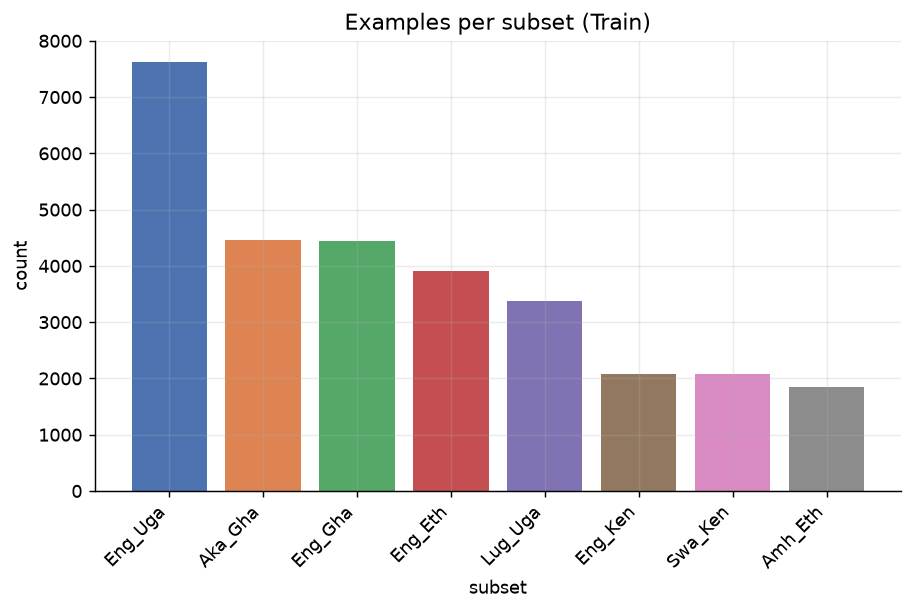

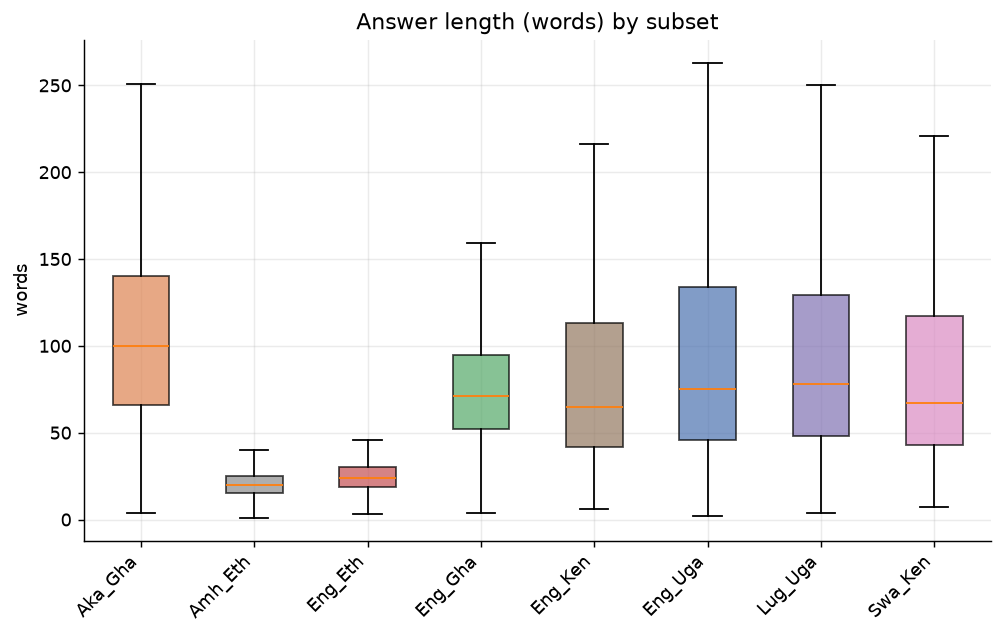

In [3]:
train = dfs["train"]
lang_tab = language.subset_table(train, has_answers=True)
io.save_table(lang_tab, "02_subset_summary_train", index=False)
display(lang_tab)
print("Imbalance:", language.imbalance_metrics(lang_tab))
display(language.script_table(train, C.INPUT_COL))
train_len = language.add_length_columns(train)
io.save_fig(viz.bar(lang_tab.set_index("subset")["n"], "Examples per subset (Train)",
                    "subset","count", color_by_subset=True), "02_counts_per_subset")
io.save_fig(viz.box_by_group(train_len, "q_words", C.SUBSET_COL,
                    "Question length (words) by subset","words"), "02_qlen_box_by_subset")
io.save_fig(viz.box_by_group(train_len, "a_words", C.SUBSET_COL,
                    "Answer length (words) by subset","words"), "02_alen_box_by_subset")
show_fig("02_counts_per_subset"); show_fig("02_alen_box_by_subset")
dec.record(Decision(id="language-imbalance", section="Language Analysis",
  observation="Subsets imbalanced (Eng_Uga 25.6% .. Amh_Eth 6.2%, 4.1x ratio).",
  evidence="02_subset_summary_train.csv; 02_counts_per_subset.png",
  impact="Pooled training over-serves English; low-resource langs risk poor quality yet count equally.",
  recommendation="Per-subset metrics; subset-balanced sampling/loss weighting; non-English-dominated retrieval.",
  priority="High", tags=["fine-tuning","evaluation","retrieval"]))
dec.record(Decision(id="amharic-script", section="Language Analysis",
  observation="Amharic uses Ge'ez script (94% Ethiopic chars); all others Latin.",
  evidence="02_script_profile_questions_train.csv",
  impact="Weak Ge'ez tokenizer coverage fragments Amharic; ROUGE behaves differently.",
  recommendation="Verify Ge'ez coverage; evaluate Amharic separately; script-aware normalization.",
  priority="High", tags=["retrieval","fine-tuning","evaluation","tokenization"]))

#### 🔧 Modelling Implications

- **4.1× imbalance** and **very different answer lengths per subset** (Amharic ~20 words vs Eng_Uga ~97)
  → use **subset-balanced sampling** and **per-subset length targets**; always report metrics per subset.
- **Amharic is Ge'ez script** → confirm the embedder/LLM tokenizers cover Ge'ez, or Amharic silently degrades.
- High TTR for Amharic/Luganda → morphologically rich, small corpora → favour **subword** models & **dense** retrieval.

## 3. Question Analysis
**Why.** Templated inputs (few intents) favour retrieval/few-shot; diverse inputs favour generation.
**What.** First words, opening n-grams, interrogative templates, a templating/diversity signature.
**How.** Determines whether lexical matching suffices or we need semantic retrieval + clustering.

Diversity signature: {'n_questions': 29395, 'n_unique_3word_prefixes': 10000, 'unique_prefix_ratio': np.float64(0.3402), 'pct_covered_by_top5_prefixes': np.float64(16.65), 'pct_covered_by_top20_prefixes': np.float64(25.51)}


,first_word,count,pct
0,what,5453,18.29
1,how,4225,14.17
2,can,1827,6.13
3,je,1369,4.59
4,is,1291,4.33
5,ɔkwan,1017,3.41
6,dɛn,733,2.46
7,if,698,2.34
8,are,641,2.15
9,does,573,1.92


,prefix,count,pct
0,what are the,1365,4.58
1,how can i,1014,3.41
2,ɔkwan bɛn so,1008,3.39
3,what is the,998,3.35
4,what are some,508,1.71
5,how can adolescents,373,1.25
6,mɛyɛ dɛn atumi,237,0.80
7,is it true,236,0.79
8,how do i,221,0.74
9,dwuma bɛn na,217,0.73


,template,count,pct
0,what,5453,30.19
1,how,4224,23.39
2,<other>,4195,23.23
3,is/are,1832,10.14
4,do/does,822,4.55
5,can/could i,374,2.07
6,why,345,1.91
7,where,193,1.07
8,which,165,0.91
9,when,139,0.77


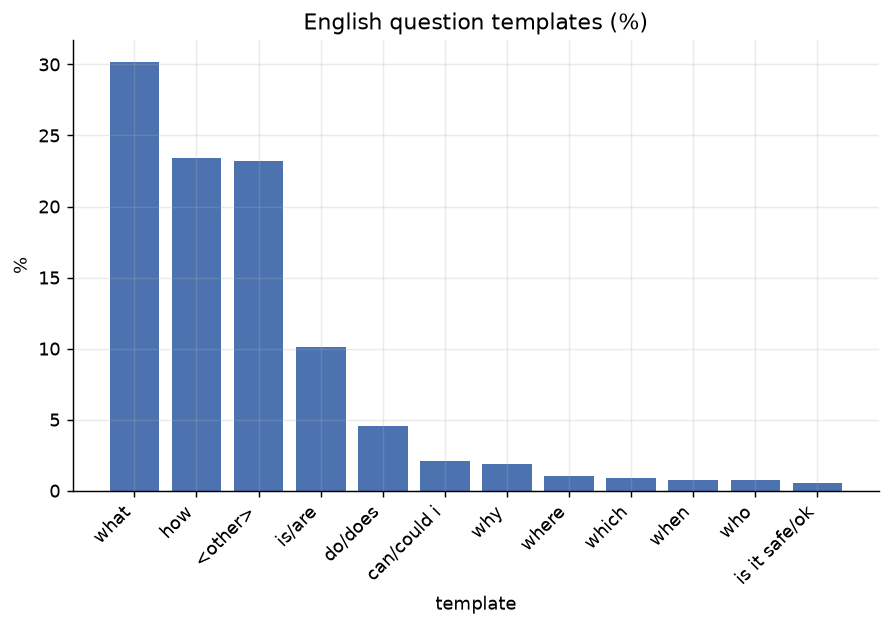

In [4]:
q = train[C.INPUT_COL]
print("Diversity signature:", Q.diversity_signature(q))
display(Q.first_word_distribution(q).head(12))
display(Q.starting_ngrams(q, 3).head(12))
eng = train[train[C.SUBSET_COL].isin(["Eng_Uga","Eng_Gha","Eng_Eth","Eng_Ken"])][C.INPUT_COL]
tmpl = Q.template_coverage(eng); display(tmpl)
io.save_fig(viz.bar(tmpl.set_index("template")["pct"].head(12),
            "English question templates (%)","template","%"), "03_question_templates_english")
show_fig("03_question_templates_english")
dec.record(Decision(id="question-templating", section="Question Analysis",
  observation="English highly templated (what 30%, how 23%, is/are 10%); African langs longer & diverse.",
  evidence="03_question_templates_english.csv, 03_question_diversity_by_subset.csv",
  impact="Templated English clusters into few intents (retrieval/few-shot friendly); diverse languages need semantic matching.",
  recommendation="Use dense/semantic retrieval esp. for African languages; intent clustering for few-shot exemplars.",
  priority="Medium", tags=["retrieval","prompting"]))

#### 🔧 Modelling Implications

- English is **highly templated** (~77% in a dozen interrogatives) → few intents → **retrieval & few-shot prompting** work well.
- Akan/Luganda/Amharic questions are **longer and more diverse** → **dense semantic** retrieval, not BM25 alone.
- Semantic intent clusters (§8) can seed **few-shot exemplars** per topic.

## 4. Answer Analysis  *(high priority)*
**Why.** The single biggest lever: are answers individually written or drawn from a canonical set?
**What.** Exact & near-duplicate reuse, reuse distribution, repeated closings/boilerplate.
**How.** If canonical, a retrieve-and-copy system can score high on ROUGE; generation only smooths gaps.

In [5]:
a = train[C.OUTPUT_COL]
print("Exact reuse:", A.exact_reuse(a))
display(A.reuse_distribution(a, 10))
print("Near-duplicate (sampled):", A.near_duplicate_estimate(a, sample=5000))
display(A.repeated_sentences(a, 10))
# The Eng_Eth topic-tag prefix (free gold labels) — see decision below.
train = train.assign(gold_topic=T.parse_eng_eth_topics(train))
display(train["gold_topic"].value_counts().head(10).rename("Eng_Eth gold topic"))
dec.record(Decision(id="answer-duplication-canonical", section="Answer Analysis",
  observation="39% exact-duplicate answers, only 4.9% dup questions -> many questions share one answer.",
  evidence="01_train_duplicates.md; 04_answer_exact_reuse",
  impact="Answers come from a canonical bank; retrieve-and-copy can match gold verbatim (high ROUGE).",
  recommendation="Retrieval-first baseline; build corpus from unique answers; treat partly as answer selection.",
  priority="High", tags=["retrieval","reranking","post-processing"]))
dec.record(Decision(id="eng-eth-topic-prefix", section="Answer Analysis",
  observation="2,215 Eng_Eth answers (only) start 'This is a question about, <TOPIC>.' with a clean label.",
  evidence="04_answer_repeated_sentences.csv",
  impact="Subset-specific style rule AND near-free gold topic labels.",
  recommendation="Parse to a topic column; post-process Eng_Eth predictions to prepend the prefix; don't leak elsewhere.",
  priority="High", tags=["post-processing","topic-modelling","prompting","evaluation"]))

Exact reuse: {'n_answers': 29815, 'n_unique_answers': 18078, 'unique_ratio': 0.6063, 'pct_answers_in_reused_group': 50.52, 'max_reuse_count': 68, 'n_answers_reused_2plus': 3327}


,rank,times_used,answer_preview
0,1,68,Chlamydia also known as Chlamydial Genitourina...
1,2,63,"This is a question about, Trichomoniasis. Tric..."
2,3,61,Most people with Genital Herpes or Herpes Simp...
3,4,61,People with symptoms of oral Genital herpes or...
4,5,60,While some people with Genital Herpes or Herpe...
5,6,57,"This is a question about, Herpes. Herpes canno..."
6,7,54,"This is a question about, Syphilis. Syphilis i..."
7,8,54,"This is a question about, HIV/AIDS. HIV cannot..."
8,9,52,"This is a question about, HPV. HPV has no cure..."
9,10,52,Chlamydia infections also known as Chlamydial ...


Near-duplicate (sampled): {'sampled': 5000, 'shingle_k': 8, 'jaccard_threshold': 0.8, 'pct_near_duplicate': 29.48}


,count,sentence
0,299,"This is a question about, HIV/AIDS"
1,197,"This is a question about, Herpes"
2,191,"This is a question about, Syphilis"
3,183,"This is a question about, HPV"
4,174,"This is a question about, Gonorrhea"
5,159,"This is a question about, Trichomoniasis"
6,158,"This is a question about, Chlamydia"
7,152,"This is a question about, General"
8,148,Chlamydia also known as Chlamydial Genitourina...
9,148,"If symptoms occur, they may not appear until s..."


gold_topic
HIV/AIDS               299
Herpes                 197
Syphilis               191
HPV                    183
Gonorrhea              174
Trichomoniasis         159
Chlamydia              158
General                152
General Information     15
Harmful Practices       10
Name: Eng_Eth gold topic, dtype: int64

#### 🔧 Modelling Implications

- Strong **canonical answer bank** (~40% exact, ~29% near-dup) → **retrieve-and-copy is a serious baseline**, not just a sanity check.
- **Eng_Eth's `This is a question about, X.` prefix** is a subset-specific **style rule** to reproduce (ROUGE) and a source of **free topic labels**.
- Repeated closings/trivia ⇒ answers are **assembled from reusable per-topic blocks** → generation should imitate this structure.

## 5. Duplicate Analysis
**Why.** Directly decides whether retrieval can win and bounds achievable accuracy.
**What.** Exact dup questions/answers/pairs; many-questions→one-answer; one-question→many-answers (ceiling).
**How.** Many→one supports answer-selection; one→many caps exact/ROUGE for any system.

In [6]:
display(D.exact_duplicate_counts(train))
m2o, m2o_tbl = D.many_questions_one_answer(train); print("many-Q -> one-A:", m2o); display(m2o_tbl.head(8))
o2m, o2m_summary = D.one_question_many_answers(train); print("one-Q -> many-A (ceiling):", o2m)
dec.record(Decision(id="answer-ambiguity-ceiling", section="Duplicate Analysis",
  observation="~4% of identical questions have >1 distinct gold answer (max 4).",
  evidence="05_one_question_many_answers_top.csv",
  impact="Irreducible variance caps exact/ROUGE; the LLM judge may be fairer.",
  recommendation="Prefer semantic eval; pick the most frequent/representative answer among variants.",
  priority="Medium", tags=["evaluation","retrieval"]))

,value,pct_of_rows
metric,,
unique_questions,28346,95.07
duplicated_questions,1469,4.93
unique_answers,18078,60.63
duplicated_answers,11737,39.37
unique_qa_pairs,29539,99.07
duplicated_qa_pairs,276,0.93


many-Q -> one-A: {'n_answers_with_multiple_distinct_questions': 3324, 'pct_answers_shared_by_multiple_questions': 18.39, 'max_distinct_questions_per_answer': 68, 'mean_distinct_questions_per_answer': 1.634}


,output,n_distinct_questions
0,Chlamydia also known as Chlamydial Genitourina...,68
1,"This is a question about, Trichomoniasis. Tric...",63
2,People with symptoms of oral Genital herpes or...,61
3,Most people with Genital Herpes or Herpes Simp...,61
4,While some people with Genital Herpes or Herpe...,60
5,"This is a question about, Herpes. Herpes canno...",57
6,"This is a question about, HIV/AIDS. HIV cannot...",54
7,"This is a question about, Syphilis. Syphilis i...",54


one-Q -> many-A (ceiling): {'n_questions_with_multiple_distinct_answers': 1183, 'pct_questions_with_ambiguous_answers': 4.17, 'max_distinct_answers_per_question': 4}


#### 🔧 Modelling Implications

- **Many→one** (up to 68 questions per answer) ⇒ framing the task partly as **answer selection** is valid.
- **One→many is only ~4%** ⇒ the ambiguity ceiling is high; a well-chosen canonical answer matches gold most of the time.
- ⇒ **ROUGE is a mostly-fair metric** here (except morphology, §11/§13), so retrieval quality translates to leaderboard.

## 6–9. Embeddings, Topics & Embedding Exploration
**Why.** Semantic structure decides whether dense retrieval and topic-routing help. **What.** e5 embeddings
for all questions; automatic topic discovery (BERTopic); 2-D UMAP by language and by topic. **How.** If
topics cluster cleanly and semantically-similar questions co-locate, dense retrieval and topic filters help.
*(Embeddings are cached to `outputs/artifacts`; first run encodes ~39k texts.)*

[embeddings] cache hit: emb_train_q_50c466ccd92222a6.npy


[embeddings] cache hit: emb_val_q_c928f509729060b3.npy


[embeddings] cache hit: emb_test_q_17b56c102c5c43a8.npy


2026-07-07 21:06:51,109 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-07-07 21:07:08,161 - BERTopic - Dimensionality - Completed ✓


...

2026-07-07 21:07:09,538 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-07-07 21:07:09,746 - BERTopic - Representation - Completed ✓


discovered topics: 67


,topic_id,label,count,pct
0,-1,<outlier/noise>,6604,22.15
1,0,"awo, ba, ka, saa, aba",4269,14.32
2,1,"virusi vya, vya, vya ukimwi, virusi, ukimwi",1859,6.24
3,2,"hpv, akawuka ka, leader, art, pid",1858,6.23
4,3,"okufuna, ntya, ki, singa, nga",1739,5.83
5,4,"services, sexual reproductive, healthcare, rep...",1609,5.40
6,5,"akawuka, omuntu, abantu, ku, nga",1493,5.01
7,6,"peer pressure, pressure, boundaries, peer, com...",655,2.20
8,7,"drugs, antiretroviral, death, live, does hiv",474,1.59
9,8,"media, literacy, digital, content, messages",341,1.14


topic validation vs Eng_Eth gold: {'n_gold_docs': 2149, 'n_clusters_evaluated': 42, 'mean_cluster_purity': 0.5879}


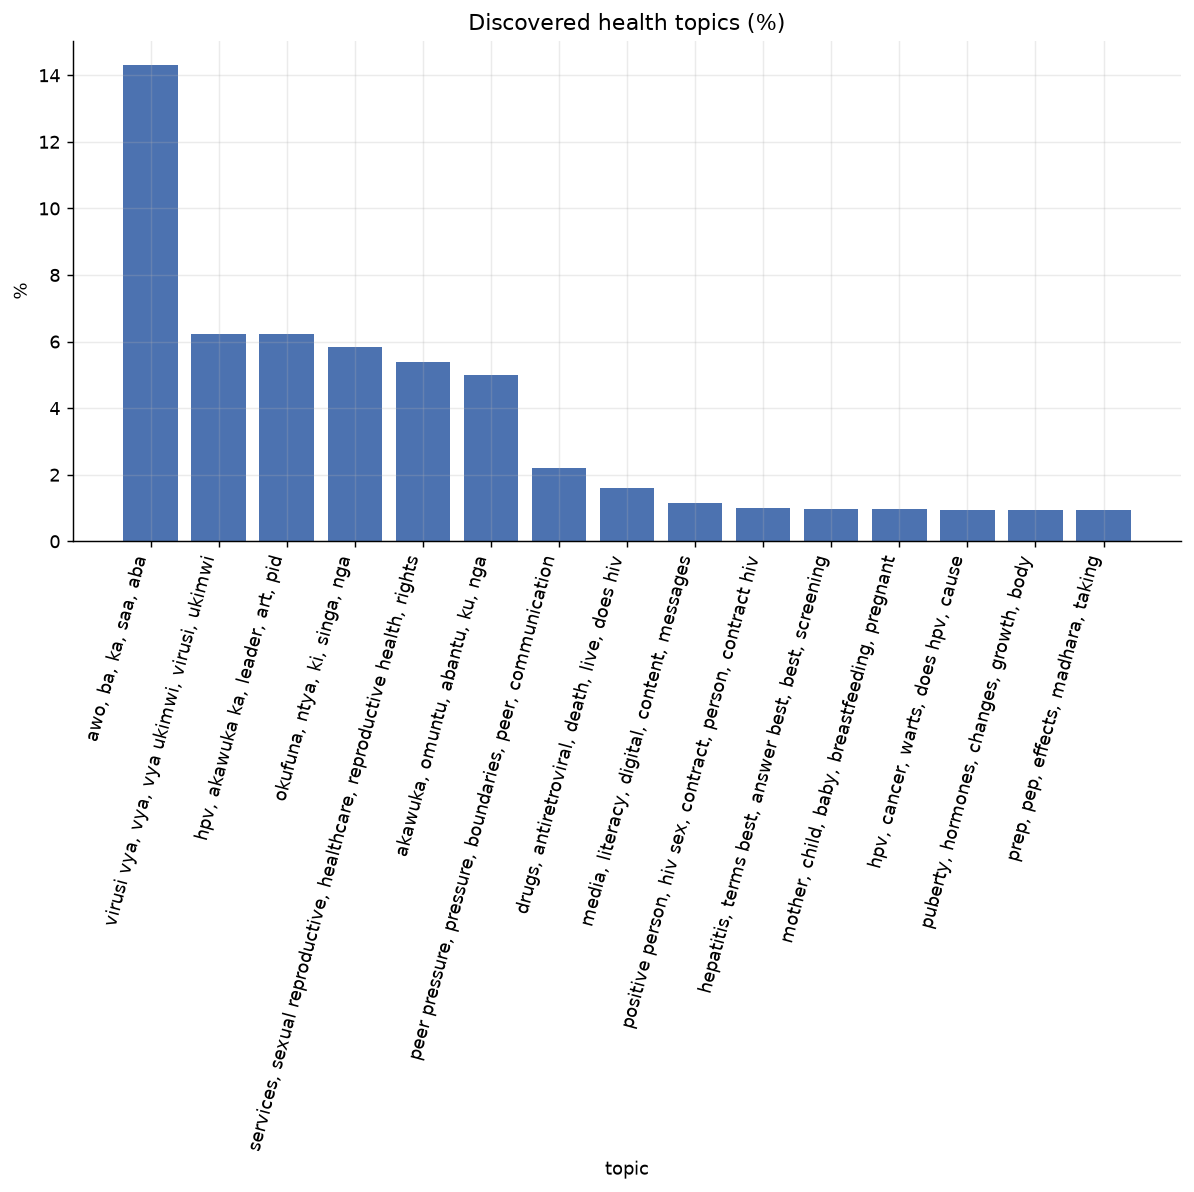

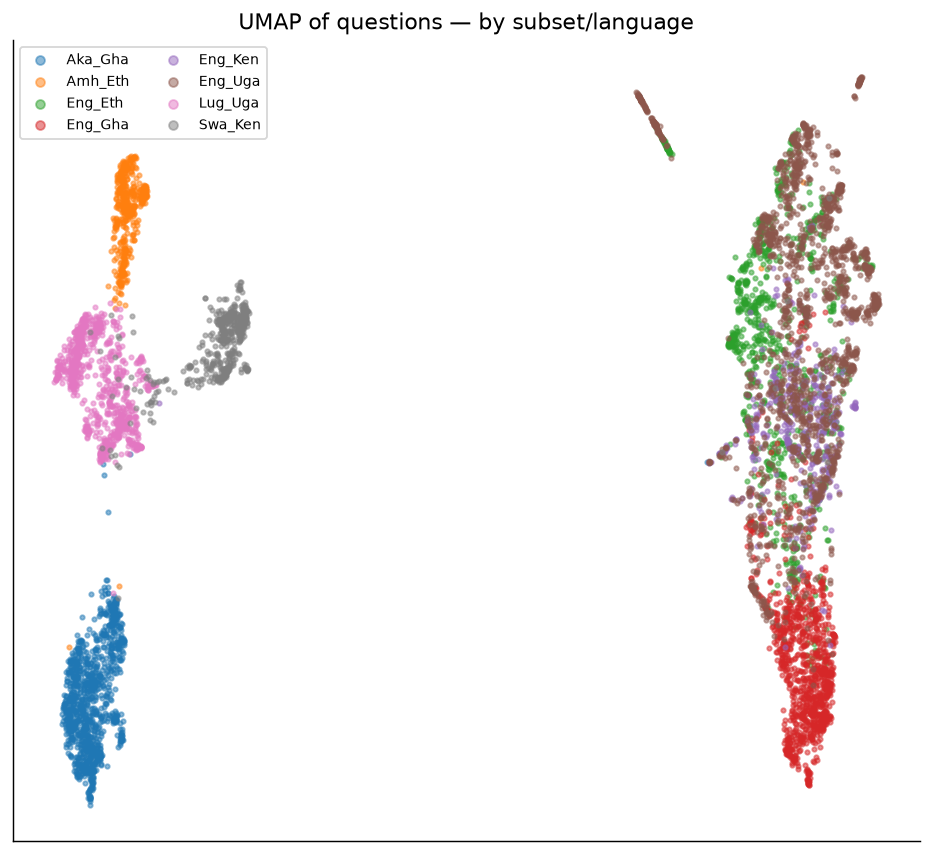

In [7]:
tr_q = train[C.INPUT_COL].tolist()
tr_emb  = E.encode(tr_q, "query", cache_name="train_q")
va_emb  = E.encode(dfs["val"][C.INPUT_COL].tolist(), "query", cache_name="val_q")
te_emb  = E.encode(dfs["test"][C.INPUT_COL].tolist(), "query", cache_name="test_q")
tmodel, tr_topics, info = T.run_bertopic(tr_q, tr_emb, min_topic_size=60)
n_topics = int((info["Topic"]!=-1).sum()); print("discovered topics:", n_topics)
dist = T.topic_distribution(tr_topics, train[C.SUBSET_COL].tolist(), tmodel)
io.save_table(dist, "08_topic_distribution", index=False); display(dist.head(15))
print("topic validation vs Eng_Eth gold:", T.validate_against_gold(tr_topics, train["gold_topic"]))
io.save_fig(viz.bar(dist[dist.topic_id!=-1].set_index("label")["pct"].head(15),
            "Discovered health topics (%)","topic","%",rotate=75,figsize=(11,5)), "08_topic_distribution")
show_fig("08_topic_distribution")
# UMAP (sampled)
rng = np.random.default_rng(C.SEED); sel = rng.choice(len(train), min(7000,len(train)), replace=False)
xy = T.umap_2d(tr_emb[sel])
io.save_fig(viz.scatter_2d(xy, train[C.SUBSET_COL].to_numpy()[sel],
            "UMAP of questions — by subset/language"), "09_umap_by_subset")
show_fig("09_umap_by_subset")
dec.record(Decision(id="topic-inventory", section="Topic Analysis",
  observation=f"BERTopic discovered {n_topics} data-driven health topics; purity vs Eng_Eth gold ~0.59.",
  evidence="08_topic_distribution.csv, 08_topic_validation.csv",
  impact="Clean topical structure enables topic-routed retrieval and topic-balanced evaluation.",
  recommendation="Store topic ids as metadata; topic filter in retrieval; report metrics per topic.",
  priority="Medium", tags=["retrieval","topic-modelling","evaluation"]))

#### 🔧 Modelling Implications

- Automatic topics recover the **SRH curriculum** (HIV/AIDS, HPV, PrEP/PEP, mother-child, puberty, peer-pressure, digital literacy) → **topic-routed retrieval** and **per-topic reporting** are viable.
- UMAP shows **low-resource languages form their own regions** (script/lexicon), while English subsets overlap → cross-lingual retrieval is harder for Amharic/Akan (confirmed §10).
- Topic labels align moderately with Eng_Eth gold (purity ~0.59) → clusters are meaningful but not perfect; use as **soft** metadata.

## 10. Retrieval Feasibility  *(highest priority)*
**Why.** Establish, with **zero training**, how far pure retrieval gets. **What.** For every Val question,
retrieve the nearest Train question (BM25, dense e5, RRF hybrid), copy its answer, and score ROUGE-1/L,
exact-match and topic-match. **How.** Sets the baseline the full system must beat and reveals where copy fails.

In [8]:
val = dfs["val"]; tr_ans = train[C.OUTPUT_COL].tolist(); va_ans = val[C.OUTPUT_COL].tolist()
tr_sub = train[C.SUBSET_COL].tolist(); va_sub = val[C.SUBSET_COL].tolist()
va_topics, _ = tmodel.transform(val[C.INPUT_COL].tolist(), embeddings=va_emb); va_topics = np.asarray(va_topics)
bm25 = R.BM25Retriever(tr_q); bm25_topk = bm25.topk(val[C.INPUT_COL].tolist(), k=5)
dense = R.DenseRetriever(tr_emb); dense_topk, dense_sim = dense.topk(va_emb, k=5)
hybrid_topk = R.rrf_fuse(bm25_topk, dense_topk, k=5)
res = {}
for name, topk, sim in [("BM25",bm25_topk,None),("dense_e5",dense_topk,dense_sim[:,0]),("hybrid",hybrid_topk,None)]:
    ev = R.evaluate(topk[:,0], tr_ans, va_ans, train_topics=tr_topics, query_topics=va_topics,
                    train_subset=tr_sub, query_subset=va_sub, dense_sim=sim)
    res[name] = R.summarize(ev)
headline = pd.concat({k:v.loc[["overall"]] for k,v in res.items()}); headline.index = headline.index.droplevel(1)
io.save_table(headline, "10_retrieval_headline"); print("HEADLINE (overall):"); display(headline.round(4))
print("Dense e5 per subset:"); display(res["dense_e5"].round(4))
dec.record(Decision(id="retrieval-feasibility", section="Retrieval Feasibility",
  observation="Zero-training retrieve-and-copy on Val reaches strong ROUGE with dense e5.",
  evidence="10_retrieval_headline.csv",
  impact="Retrieval-only is a strong baseline; generation must beat/refine it.",
  recommendation="Adopt dense retrieval baseline; use retrieved answer as RAG context; rerank top-k.",
  priority="High", tags=["retrieval","reranking","architecture"]))
dec.record(Decision(id="dense-beats-hybrid", section="Retrieval Feasibility",
  observation="Dense e5 > naive RRF hybrid > BM25; fusing weak BM25 hurt dense.",
  evidence="10_retrieval_headline.csv",
  impact="'Hybrid is best' is FALSE with untuned RRF; dense is the strongest signal.",
  recommendation="Default to dense; add BM25 only via TUNED fusion / rare-term fallback; validate any hybrid beats dense.",
  priority="High", tags=["retrieval","architecture"]))
dec.record(Decision(id="retrieval-quality-by-subset", section="Retrieval Feasibility",
  observation="ROUGE-L: Ken/Uga/Swa/Lug strong (0.47-0.66) vs Eng_Gha/Akan/Amharic weak (0.17-0.21).",
  evidence="10_retrieval_hybrid_summary.md",
  impact="Retrieval alone underperforms on Amharic/Akan/Eng_Gha; those need generation.",
  recommendation="Route by subset+confidence: copy where dense-sim high; generate for Amharic/Akan/Eng_Gha.",
  priority="High", tags=["architecture","retrieval","evaluation"]))

2026-07-07 21:07:16,940 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.


2026-07-07 21:07:22,601 - BERTopic - Dimensionality - Completed ✓


2026-07-07 21:07:22,601 - BERTopic - Clustering - Approximating new points with `hdbscan_model`


2026-07-07 21:07:22,742 - BERTopic - Cluster - Completed ✓


BM25 retrieve:   0%|          | 0/6686 [00:00<?, ?it/s]

...

dense retrieve: 100%|██████████| 14/14 [00:01<00:00, 10.50it/s]

HEADLINE (overall):


,rouge1_f1,rougeL_f1,exact,topic_match,subset_match,retrieval_sim
BM25,0.4513,0.3830,0.2073,0.7948,0.9200,NaN
dense_e5,0.5077,0.4419,0.2626,0.9053,0.9227,0.9613
hybrid,0.4879,0.4213,0.2435,0.8522,0.9251,NaN


Dense e5 per subset:


,rouge1_f1,rougeL_f1,exact,topic_match,subset_match,retrieval_sim
overall,0.5077,0.4419,0.2626,0.9053,0.9227,0.9613
Aka_Gha,0.3235,0.1895,0.0009,0.9964,0.9991,0.9627
Amh_Eth,0.1853,0.1721,0.0043,0.9805,0.9827,0.9532
Eng_Eth,0.5626,0.5298,0.1702,0.8369,0.8918,0.9660
Eng_Gha,0.3372,0.2154,0.0091,0.7763,0.9493,0.9393
Eng_Ken,0.7803,0.7529,0.6256,0.8462,0.6385,0.9658
Eng_Uga,0.7017,0.6622,0.4757,0.8987,0.8673,0.9749
Lug_Uga,0.4745,0.4296,0.3345,0.9764,0.9976,0.9643
Swa_Ken,0.7118,0.6809,0.6120,0.9421,0.9537,0.9549


#### 🔧 Modelling Implications

- **Dense e5 retrieve-and-copy is a strong zero-training baseline** and **beats the naive hybrid** — do not assume RRF hybrid wins; validate it.
- Retrieval **near-solves Kenya/Uganda/Swahili/Luganda** but **fails Amharic/Akan/Eng_Ghana** → a single strategy is wrong; **route by subset & confidence**.
- Use the retrieved answer as **RAG context** for a generator; add a **reranker** over top-k.

## 11. Similarity Analysis
**Why.** Understand the geometry: do languages/answers cluster, and do questions determine answers?
**What.** Subset-centroid similarity (Q & A), intra-subset density (redundancy), Q→A coupling vs shuffled.
**How.** A positive Q→A coupling gap validates question-based retrieval; dense clusters flag redundancy.

[embeddings] cache hit: emb_train_a_de7876bf66dec7d0.npy


,subset,n_sampled,mean_intra_cosine
0,Aka_Gha,1500,0.9021
6,Lug_Uga,1500,0.8798
1,Amh_Eth,1500,0.8740
5,Eng_Uga,1500,0.8334
4,Eng_Ken,1500,0.8313
7,Swa_Ken,1500,0.8302
2,Eng_Eth,1500,0.8207
3,Eng_Gha,1500,0.8198


Q-A coupling: {'mean_true_qa_cosine': 0.8687, 'mean_shuffled_qa_cosine': 0.7742, 'coupling_gap': 0.0945}


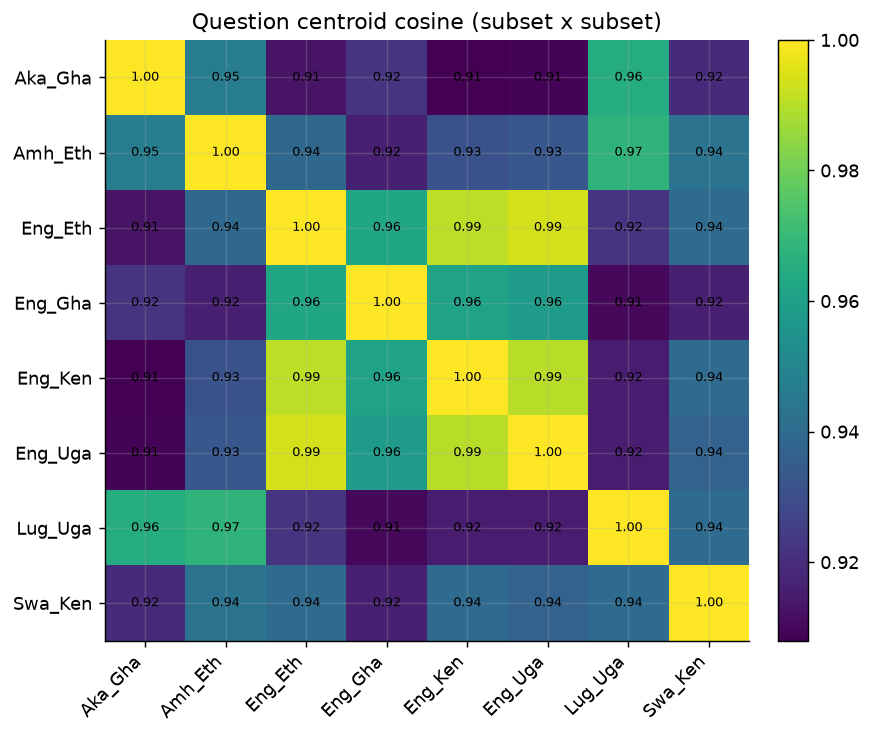

In [9]:
tr_a_emb = E.encode(tr_ans, "passage", cache_name="train_a")
qq = SIM.centroid_similarity(tr_emb, np.array(tr_sub)); io.save_table(qq, "11_centroid_sim_questions")
display(SIM.intra_subset_density(tr_emb, np.array(tr_sub)))
print("Q-A coupling:", SIM.question_answer_coupling(tr_emb, tr_a_emb))
io.save_fig(viz.heatmap(qq.to_numpy(), list(qq.index),
            "Question centroid cosine (subset x subset)"), "11_centroid_sim_questions")
show_fig("11_centroid_sim_questions")
dec.record(Decision(id="qa-coupling", section="Similarity Analysis",
  observation="True Q-A cosine 0.87 vs shuffled 0.77 (gap 0.09).",
  evidence="11_qa_coupling.csv",
  impact="Questions determine answers -> question-based retrieval signal is real.",
  recommendation="Rely on question retrieval; optionally add answer-space reranking.",
  priority="Medium", tags=["retrieval","reranking"]))

#### 🔧 Modelling Implications

- **Positive Q→A coupling gap** ⇒ questions genuinely predict answers → question-based retrieval is sound.
- **Low-resource subsets are the densest** (most self-similar questions) yet score worst on ROUGE (§13) → density ≠ easy; the bottleneck is surface scoring, not retrieval.
- Cross-subset centroid similarity guides **cross-lingual** vs **within-language** retrieval choices.

## 6b. Cross-language Analysis
**Why.** If subsets are translations, cross-lingual retrieval / pivot-through-English becomes powerful.
**What.** (1) Do ID hash-suffixes recur across subsets? (2) How close are non-English questions to their
nearest English question vs the English–English baseline? **How.** Determines whether we can share
answers across languages or must serve each language independently.

In [10]:
sid = XL.shared_id_analysis(train); print("shared-ID analysis:", sid)
align = XL.embedding_alignment(tr_emb, np.array(tr_sub)); io.save_table(align, "06_embedding_alignment", index=False)
display(align)
dec.record(Decision(id="cross-lingual-parallelism", section="Cross-language Analysis",
  observation="NO parallelism: 0% shared IDs; non-Eng->Eng cosine ~0.85-0.87 vs 0.94-0.98 Eng-Eng.",
  evidence="06_shared_id_analysis, 06_embedding_alignment",
  impact="No aligned/parallel data; English answers are not guaranteed translations.",
  recommendation="No pivot-through-English assumption; retrieve within-language; treat cross-lingual reuse as topical.",
  priority="High", tags=["architecture","retrieval","data"]))

shared-ID analysis: {'n_unique_suffixes': 29815, 'n_suffixes_in_multiple_subsets': 0, 'pct_suffixes_shared': 0.0, 'max_subsets_per_suffix': 1, 'mean_subsets_per_shared_suffix': 0}


,subset,is_english,mean_max_cos_to_english,median_max_cos_to_english,p90_max_cos_to_english
0,Aka_Gha,False,0.8601,0.8590,0.8748
1,Amh_Eth,False,0.8726,0.8723,0.8971
2,Eng_Eth,True,0.9813,0.9964,1.0000
3,Eng_Gha,True,0.9393,0.9394,0.9659
4,Eng_Ken,True,0.9735,0.9774,1.0000
5,Eng_Uga,True,0.9771,0.9852,0.9993
6,Lug_Uga,False,0.8528,0.8548,0.8755
7,Swa_Ken,False,0.8749,0.8766,0.9089


#### 🔧 Modelling Implications

- **Not translations**: IDs are unique per subset and non-English questions are only ~0.86 cosine to English (vs 0.95+ English–English) → **do not build a pivot-through-English pipeline** assuming parallel data.
- Cross-lingual answer reuse is **topical, not exact** → prefer **within-language retrieval**, use cross-lingual only as a fallback.

## 7. Vocabulary Analysis · 12. Answer Style · 13. Language Complexity
**Why.** Tokenizer choice, OOV risk, and whether a generator should imitate style. **What.** Per-language
vocab/OOV/medical density; sentence counts, disclaimers, readability; words-per-sentence, TTR, Unicode.
**How.** High OOV → subword models & dense retrieval; rare disclaimers → don't add boilerplate; per-subset
length/style → per-subset generation targets.

In [11]:
display(V.per_language_vocab(train, C.INPUT_COL))
display(V.oov_between_splits(train, dfs["val"], C.INPUT_COL))
display(ST.style_by_subset(train)); display(ST.disclaimer_frequency(train))
display(CX.complexity_by_subset(train, C.OUTPUT_COL))
display(CX.unicode_blocks(train, C.OUTPUT_COL))
dec.record(Decision(id="answer-style-and-disclaimers", section="Answer Style",
  observation="Disclaimers <1%; per-subset length/complexity varies widely; bullets <2%.",
  evidence="12_style_by_subset.md, 12_disclaimers.md",
  impact="Appending disclaimers/bullets diverges from gold and loses ROUGE.",
  recommendation="Match per-subset length & plain prose; suppress unsolicited disclaimers.",
  priority="Medium", tags=["prompting","fine-tuning","post-processing"]))
dec.record(Decision(id="oov-subword-tokenization", section="Vocabulary Analysis",
  observation="High train->val OOV: Amharic 37%/16% type/token, Lug 26%, Swa 25%, Aka 20%.",
  evidence="07_oov_train_val_questions.md",
  impact="Word-level features miss surface forms in morphologically rich languages; hurts BM25 & word heads.",
  recommendation="Use subword/byte tokenizers and dense retrieval for these languages.",
  priority="Medium", tags=["tokenization","retrieval","fine-tuning"]))

,subset,tokens_total,vocab_size,ttr,hapax,hapax_pct_of_vocab,medical_token_pct
1,Amh_Eth,17730,4582,0.2584,2897,63.2,0.558
6,Lug_Uga,39383,4213,0.1070,2238,53.1,0.284
0,Aka_Gha,128784,4026,0.0313,1889,46.9,0.263
3,Eng_Gha,90272,3399,0.0377,1179,34.7,1.620
5,Eng_Uga,86305,2678,0.0310,900,33.6,9.665
2,Eng_Eth,48341,2447,0.0506,520,21.3,9.023
7,Swa_Ken,23478,2337,0.0995,1153,49.3,0.515
4,Eng_Ken,24321,1994,0.0820,762,38.2,9.967


,subset,other_vocab,oov_types,oov_type_pct,oov_token_pct
0,Aka_Gha,2054,415,20.20,1.43
1,Amh_Eth,1793,667,37.20,15.78
2,Eng_Eth,851,88,10.34,1.93
3,Eng_Gha,2019,264,13.08,1.34
4,Eng_Ken,905,151,16.69,3.57
5,Eng_Uga,1391,141,10.14,0.78
6,Lug_Uga,1959,505,25.78,5.33
7,Swa_Ken,1130,280,24.78,5.03


,subset,mean_sentences,median_sentences,pct_with_bullets,flesch_reading_ease
5,Eng_Uga,5.39,4,2.01,33.0
6,Lug_Uga,4.26,4,0.27,NaN
3,Eng_Gha,3.89,3,0.05,3.9
0,Aka_Gha,3.87,4,0.04,NaN
7,Swa_Ken,3.87,3,0.00,NaN
4,Eng_Ken,3.74,3,0.00,31.8
2,Eng_Eth,2.64,3,0.33,48.3
1,Amh_Eth,1.90,2,0.43,NaN


,disclaimer,count,pct_of_answers
1,seek_medical,214,0.72
4,talk_to,188,0.63
0,consult_professional,119,0.40
3,see_a_doctor,39,0.13
2,not_medical_advice,0,0.00


,subset,mean_words_per_sentence,ttr,vocab_size
0,Aka_Gha,30.34,0.0185,8754
6,Lug_Uga,22.25,0.0260,7957
3,Eng_Gha,21.86,0.0250,8502
4,Eng_Ken,21.84,0.0234,3936
7,Swa_Ken,21.57,0.0260,4554
5,Eng_Uga,19.88,0.0075,5582
1,Amh_Eth,12.55,0.2144,8109
2,Eng_Eth,10.56,0.0414,4056


,subset,chars,top_unicode_blocks,control_chars,nonascii_symbols
0,Aka_Gha,2428257,"LATIN:78.3%, SPACE:19.2%, COMMA:1.0%, FULL:0.7%",0,1626
1,Amh_Eth,193939,"ETHIOPIC:79.0%, SPACE:18.4%, LATIN:1.3%, RIGHT...",2,5153
2,Eng_Eth,594512,"LATIN:80.6%, SPACE:15.5%, FULL:1.7%, COMMA:1.3%",0,115
3,Eng_Gha,2471307,"LATIN:84.0%, SPACE:13.4%, COMMA:1.0%, FULL:0.7%",0,257
4,Eng_Ken,1058047,"LATIN:82.0%, SPACE:15.3%, COMMA:1.0%, FULL:0.7%",5,333
5,Eng_Uga,4631510,"LATIN:81.0%, SPACE:16.0%, COMMA:1.0%, FULL:0.9%",833,3490
6,Lug_Uga,2195272,"LATIN:84.2%, SPACE:12.5%, APOSTROPHE:1.0%, COM...",0,13557
7,Swa_Ken,1121517,"LATIN:82.4%, SPACE:15.4%, COMMA:1.0%, FULL:0.7%",0,120


#### 🔧 Modelling Implications

- **Severe OOV** for Amharic/Luganda/Swahili/Akan → **subword/byte-level** models & **dense** retrieval, not lexical.
- **Disclaimers are rare & bullets minimal** → a generator must **not** add safety boilerplate → protect ROUGE.
- **Per-subset length/complexity** varies 5× → set **per-subset max-length & style targets**.

## 14–15. Validation & Test Distribution
**Why.** Can we trust Val as a proxy for Test, and will retrieval generalise? **What.** Language mix,
question-length KS tests, and each Val/Test question's nearest-Train cosine. **How.** No shift ⇒ tune
thresholds on Val and trust them on Test; a low-similarity tail marks questions needing generation.

In [12]:
display(DIST.language_mix(train, dfs["val"]))
display(DIST.length_ks(train, dfs["val"], C.INPUT_COL))
val_sim = DIST.nearest_train_similarity(va_emb, tr_emb, dfs["val"][C.SUBSET_COL].to_numpy())
test_sim = DIST.nearest_train_similarity(te_emb, tr_emb, dfs["test"][C.SUBSET_COL].to_numpy())
io.save_table(val_sim, "14_val_nearest_train_sim", index=False); io.save_table(test_sim, "15_test_nearest_train_sim", index=False)
print("Val nearest-train:"); display(val_sim); print("Test nearest-train:"); display(test_sim)
dec.record(Decision(id="no-distribution-shift", section="Validation / Test Distribution",
  observation="Val & Test ~= Train (nearest-Train cosine ~0.96, p10 0.93); language mix +/-5pp.",
  evidence="14_val_nearest_train_sim.md, 15_test_nearest_train_sim.md",
  impact="Low shift risk; Val is a reliable Test proxy; retrieval generalises; Eng_Gha most novel.",
  recommendation="Tune routing/rerank thresholds on Val and trust for Test; extra attention to Eng_Gha.",
  priority="High", tags=["evaluation","architecture","retrieval"]))
dec.record(Decision(id="rouge-morphology-gap", section="Retrieval Feasibility / Complexity",
  observation="Amharic/Akan: high topic-match (0.97-0.99) but low ROUGE (0.17-0.20); rich morphology, 16% Amharic token-OOV.",
  evidence="10_retrieval_hybrid_summary.md, 13_complexity_answers.md",
  impact="Word-ROUGE under-scores correct morphologically-rich answers; generation unlikely to beat copy on surface ROUGE.",
  recommendation="Report per-subset ROUGE; char/stemmed ROUGE diagnostics; optimise these subsets toward the LLM judge.",
  priority="High", tags=["evaluation","tokenization","architecture"]))

,train_pct,other_pct,delta_pp
subset,,,
Eng_Uga,25.57,25.25,-0.32
Aka_Gha,14.94,16.66,1.72
Eng_Gha,14.90,16.51,1.61
Eng_Eth,13.13,8.44,-4.69
Lug_Uga,11.35,12.65,1.30
Eng_Ken,6.98,5.83,-1.15
Swa_Ken,6.94,7.75,0.81
Amh_Eth,6.19,6.91,0.72


,subset,train_mean,other_mean,ks_stat,ks_pvalue,same_dist_at_0.05
0,Aka_Gha,28.9,28.1,0.0316,0.32900,True
1,Amh_Eth,9.6,9.8,0.0318,0.83400,True
2,Eng_Eth,12.3,11.7,0.0849,0.00154,False
3,Eng_Gha,20.3,20.2,0.0169,0.95800,True
4,Eng_Ken,11.7,11.6,0.0317,0.88500,True
5,Eng_Uga,11.3,11.4,0.0088,1.00000,True
6,Lug_Uga,11.6,11.9,0.0528,0.04430,False
7,Swa_Ken,11.3,11.7,0.0506,0.22900,True


Val nearest-train:


,subset,mean,median,p10,p90
0,Aka_Gha,0.9627,0.9634,0.9479,0.9761
1,Amh_Eth,0.9532,0.9515,0.9229,0.9892
2,Eng_Eth,0.9660,0.9755,0.9117,0.9958
3,Eng_Gha,0.9393,0.9386,0.9129,0.9675
4,Eng_Ken,0.9658,0.9706,0.9339,0.9908
5,Eng_Uga,0.9749,0.9838,0.9402,0.9948
6,Lug_Uga,0.9643,0.9656,0.9440,0.9826
7,Swa_Ken,0.9549,0.9574,0.9215,0.9847
8,OVERALL,0.9613,0.9646,0.9272,0.9908


Test nearest-train:


,subset,mean,median,p10,p90
0,Aka_Gha,0.9620,0.9632,0.9478,0.9756
1,Amh_Eth,0.9510,0.9524,0.9183,0.9849
2,Eng_Eth,0.9718,0.9822,0.9321,0.9975
3,Eng_Gha,0.9399,0.9407,0.9144,0.9661
4,Eng_Ken,0.9639,0.9674,0.9298,0.9899
5,Eng_Uga,0.9760,0.9851,0.9432,0.9946
6,Lug_Uga,0.9635,0.9660,0.9433,0.9835
7,Swa_Ken,0.9550,0.9601,0.9198,0.9838
8,OVERALL,0.9615,0.9640,0.9285,0.9900


#### 🔧 Modelling Implications

- **No distribution shift** → **tune all thresholds on Val**; results transfer to Test. **Eng_Gha** is the most novel/hardest.
- The **ROUGE/morphology gap** (right answer, low word-overlap) means Amharic/Akan should be **optimised toward the LLM judge**, not surface ROUGE.

## 16. Modelling Recommendations & 17. Final Report
Synthesise all evidence into `DATASET_ANALYSIS_REPORT.md` and print the prioritised
`MODELLING_DECISIONS.md`. See the report for the full recommended architecture and rationale.

In [13]:
text = report.build_report()
print(f"Wrote {C.REPORT_MD} ({len(text):,} chars) and {C.DECISIONS_MD}")
print("\n=== MODELLING_DECISIONS.md (head) ===\n")
print(C.DECISIONS_MD.read_text()[:1500])

Wrote /Users/zolekafuyana/Desktop/data_exploration/DATASET_ANALYSIS_REPORT.md (15,056 chars) and /Users/zolekafuyana/Desktop/data_exploration/MODELLING_DECISIONS.md

=== MODELLING_DECISIONS.md (head) ===

# Modelling Decisions

> Auto-generated by the EDA. Each entry is an **evidence-driven** finding that should shape the retrieval + multilingual LLM system. Sorted by priority.

**Total findings:** 16 (High: 10, Medium: 6, Low: 0)

## [High] answer-duplication-canonical — Answer Analysis

- **Observation:** 39% exact-duplicate answers, only 4.9% dup questions -> many questions share one answer.
- **Evidence:** 01_train_duplicates.md; 04_answer_exact_reuse
- **Likely impact:** Answers come from a canonical bank; retrieve-and-copy can match gold verbatim (high ROUGE).
- **Recommended action:** Retrieval-first baseline; build corpus from unique answers; treat partly as answer selection.
- **Tags:** retrieval, reranking, post-processing

## [High] eng-eth-topic-prefix — Answer Analysis

- 

### Recommended pipeline (evidence → decision)
1. **Dense e5 retrieval** over the Train corpus — *strongest zero-training baseline, canonical answers* (§4, §10).
2. **Rerank** top-k (cross-encoder / answer-side) — *Q→A coupling is real* (§11).
3. **Confidence routing** (nearest-Train cosine, tuned on Val≈Test): high→copy/edit; low→**generate (RAG)** — *per-subset variance & failure tail* (§10, §14).
4. **Multilingual instruction-tuned decoder LLM** for generation; **LoRA** for style/low-resource adaptation with **subset-balanced** data (§2).
5. **Per-subset post-processing**: length/style match, Eng_Eth prefix, no added disclaimers (§4, §12).
6. **Evaluate per subset** on ROUGE **and** an LLM-judge proxy; optimise Amharic/Akan toward the judge (§13).

**Bottom line:** a **hybrid retrieval + multilingual generation** system, routed by confidence and tuned per subset,
should outperform both pure retrieval (fails low-resource) and a pure generator (ignores the canonical bank the metric rewards).